# Simulating Habitable Worlds Observatory Spectra with POSEIDON

In this tutorial, we will go over creating a modern Earth spectra worthy of your favorite next-generation high-contrast imaging telescope.

We will cover the following three things in this tutorial:

1. Creating a "simple" Earth spectra
2. Using external atmospheric and surface models for a more complex Earth
3. Simulating HWO-like noise to the spectra

The Earth models use laboratory-based measurements to created the reflected-light continuum.
The simple model contains uniform vertical mixing ratios and an isotherm PT structure.
The surface is made up of only four components.
For the more complex models, we will use custom atmospheric and surface models.
We will also show how the pressure grid must be adjusted to account for Earth-like clouds in the spectra, which may not be instantly intuitive.

By the end, you will be able to create modern Earth models in POSEIDON like the one below from [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract).

<img src="../../_static/paper_images/Zelakiewicz_2026.png" />

### Defining bulk planetary parameters

Below, we will first start by defining the `star` and `planet` objects that will remain constant throughout both models.
The bulk paramters for the Earth are set to $R_p=1~R_\oplus$, $M_p=1~M_\oplus$, and $r_p=1~{\rm AU}$.
The star, which for our case is the Sun, is assumed to have $R_s=1~R_\odot$, $T_s=5772~{\rm K}$, $\log_{10}(g[{\rm cm/s^2}]) = 4.4$, and ${\rm [Fe/H]=0}$.
Like usual within POSEIDON, all quantities need to be converted to S.I. units where applicable.


We will also define the high-resolution (we will use $\mathcal{R}=\lambda/\Delta\lambda=10^5$) wavelength grid.

In [1]:
from POSEIDON.constants import R_Sun, R_E, M_E
from POSEIDON.core import create_planet, create_star, wl_grid_constant_R

from scipy.constants import au
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.4     # Minimum wavelength (um)
wl_max = 1.8     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

# Create the wavelength grid
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define planet properties *****#

planet_name = 'Earth'  # Planet name used for plots, output files etc.

R_p = 1.0 * R_E    # Planetary radius (m)
M_p = 1.0 * M_E    # Planetary mass (kg)
d = 10.0 * pc   # Distance to system (m)
a_p = 1.0 * au   # Planetary semi-major axis (m)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, a_p = a_p, d = d)


#***** Define stellar properties *****#

R_s = 1. * R_Sun   # Stellar radius (m)
T_s = 5772.         # Stellar effective temperature (K)
Met_s = 0.       # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] 
log_g_s = 4.4     # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

### 1. Creating Simple Modern Earth Spectra

We will create a simple modern Earth model, which is useful for benchmarking, identical to the "50\% Cloud Cover" model from [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract).

### Surface:
While POSEIDON has three surface options in `define_model()`, we will focus on using `lab_data`. We will assume the Earth is made of four surfaces: ocean, forest, snow, and sand. Each of these surfaces will be assigned the coverage $f_{\rm ocean}=0.70$, $f_{\rm forest}=0.15$, $f_{\rm snow}=0.05$, and $f_{\rm sand}=0.10$. The spectra using in [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract) are provided natively in POSEIDON; ocean, aspen leaf, and quartz sand from [USGS Spectral Library Version 7 (Kokaly et al. 2017)](https://www.usgs.gov/labs/spectroscopy-lab/usgs-spectral-library) and antarctic spectra. from [Grenfell et al. 1994](https://ui.adsabs.harvard.edu/abs/1994JGR....9918669G/abstract).

### Atmosphere:
The atmosphere will be isothermal with constant vertical mixing ratios of ${\rm H_2O}$, ${\rm O_2}$, ${\rm O_3}$, and an ${\rm N_2}$ background gas. We will also assume a patchy 50\% coverage of optically thick water clouds using Mie theory.

In [2]:
from POSEIDON.core import define_model

#***** Define model *****#

model_name = 'simple_Earth'

# Atmosphere species
bulk_species = ['N2']
param_species = ['H2O', 'O3', 'O2']
log_X_params = [-3, -6, -0.7]

# Surface properties
surfaces = {
    'USGS_ocean_Z26': 0.70,
    'USGS_aspen_Z26': 0.15,
    'Grenfell1994_antarctic_Z26': 0.05,
    'USGS_quartz_sand_Z26': 0.10
    }

PT_profile = 'isotherm'
X_profile = 'isochem'

surface_components = list(surfaces.keys())

model = define_model(model_name, bulk_species, param_species, 
                        PT_profile = PT_profile, X_profile = X_profile,
                        radius_unit = 'R_E', mass_unit = 'M_E', surface = True,  # <----- Set surface = True
                        reflection = True, # <----- Set reflection to True
                        surface_model = 'lab_data',  # <----- Set surface_model to 'lab_data'
                        cloud_model = 'Mie', cloud_type = 'slab', aerosol_species = ['H2O'], cloud_dim = 2, 
                        surface_components = surface_components, # <----- Input surface_components
                        )

### Pressure Grid

For modern Earth, clouds exist close to the surface in pressure space and are relatively thin. If we use a "standard" pressure grid, we will either significantly over- or underestimate their spectral contribution. Thus, we may want finer pressure spacing towards the surface to capture this while making it coarser in the upper atmosphere for computational efficiency.

To do this, we will place 150 layers between $10^1$ and $10^{-2}$ bar and 50 layers from $10^{-2}$ and $10^{-6}$ bar. Placing the highest pressure below the 1 bar surface is fine because it will get cut off through the assignment of the `log_P_surf` variable.

In [3]:
import numpy as np
from POSEIDON.core import make_atmosphere

# Specify the pressure grid of the atmosphere
P_min = 1.0e-6
P_mid = 1.0e-2
P_max = 1.0e1

P_top = np.logspace(np.log10(P_min), np.log10(P_mid), 50)
P_bot = np.logspace(np.log10(P_mid), np.log10(P_max), 150)
P = np.concatenate((P_top, P_bot))
# Making sure there are no duplicate pressures
P = np.unique(P)
P = P[::-1]

# Make the atmosphere model
P_ref = 1.     # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure

# Surface pressure is 1 bar
log_P_surf = 0.

#**** Surface parameters ****#

# Surface parameters are defined by surface pressure then the parameters describing the surface
# The order must match the order of the surface components defined in the model
# (i.e. surfaces['USGS_ocean_Z26'] must be in the same order as 'USGS_ocean_Z26' in surface_components)
surface_params = [
    log_P_surf, 
    surfaces['USGS_ocean_Z26'], # 0.70 for ocean
    surfaces['USGS_aspen_Z26'], # 0.15 for aspen
    surfaces['Grenfell1994_antarctic_Z26'], # 0.05 for antarctic
    surfaces['USGS_quartz_sand_Z26'] # 0.10 for quartz sand
]

# Short hand to easily create the surface params (Aiden prefers this way, especially when there are MANY surfaces)
# surface_params = [log_P_surf] + [surfaces[comp] for comp in surface_components]
# surface_params = np.array(surface_params)

# If you were using the `constant` albedo surface model, this same list would be
# albedo = 0.3
# surface_params = [log_P_surf, albedo]

#**** Cloud parameters ****#
f_cloud = 0.5 # Cloud fraction
log_P_top_slab_H2O = np.log10(0.5) # Cloud top pressure of 0.5 bar
Delta_log_P_H2O = np.log10(0.6) - np.log10(0.5) # Delta_log_P = log10(P_bottom) - log10(P_top)
log_r_m_H2O = np.log10(1.) # 1 micron mean particle size
log_X_H2O = -3. # Cloud mixing ratio (log10)

cloud_params = [f_cloud, log_P_top_slab_H2O, Delta_log_P_H2O, log_r_m_H2O, log_X_H2O]

# Generate the atmosphere

atmosphere = make_atmosphere(planet, model, P, P_ref, R_p_ref, 
                            log_X_params = log_X_params, PT_params=[300], # Isothermal T-P profile with T = 300 K
                            surface_params = surface_params,  #<---- Put surface params into make_atmosphere
                            cloud_params=cloud_params)

### Reading in the opacities

Because we are in a lower temperature regime, we must use the `Temperate` opacity database within POSEIDON.

In [4]:
from POSEIDON.core import read_opacities

#***** Read opacity data *****#
opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the Earth P-T profile
T_fine_max = 400     # 400 K upper limit covers the Earth P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 1.0    # 10 bar
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine, opacity_database = 'Temperate')

Reading in cross sections in opacity sampling mode...
N2-N2 done
N2-H2O done
O2-O2 done
O2-N2 done
H2O done
O3 done
O2 done
Reading in database for aerosol cross sections...
Opacity pre-interpolation complete.


Let's look at what the atmosphere looks like.

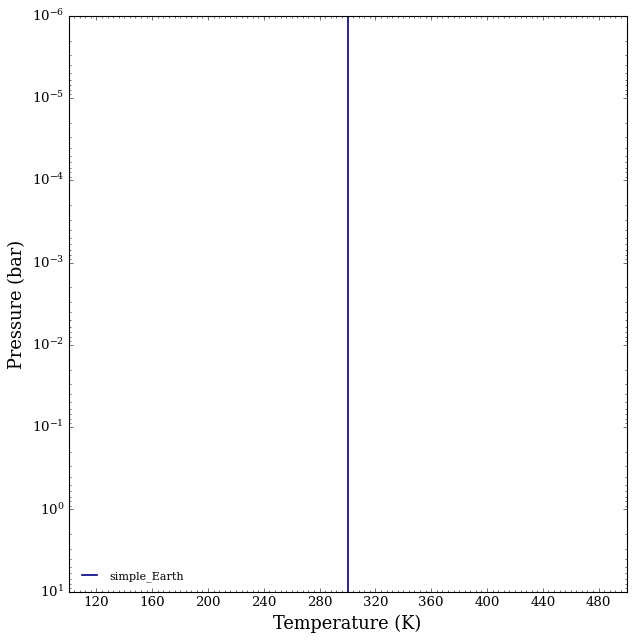

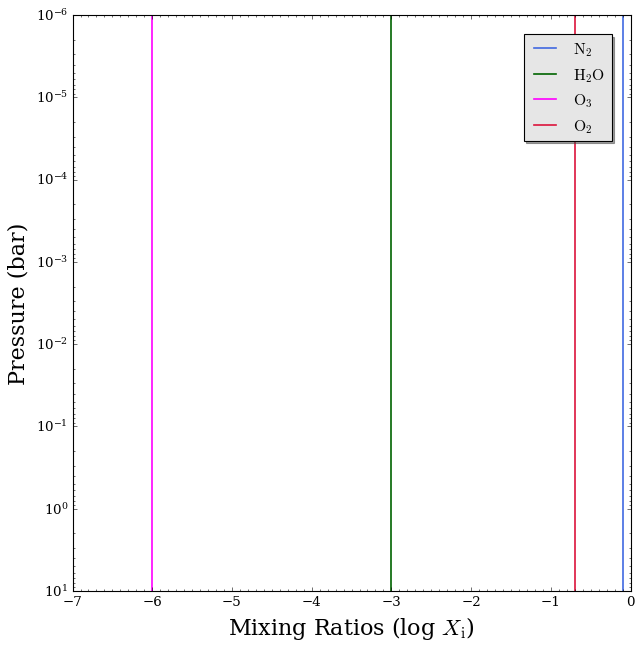

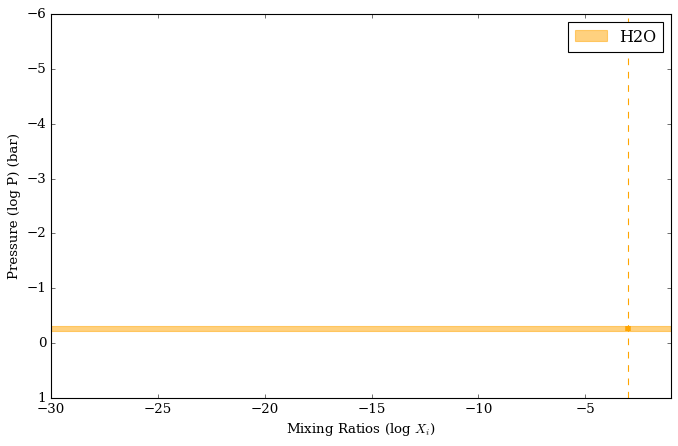

In [5]:
from POSEIDON.clouds import plot_clouds
from POSEIDON.visuals import plot_PT, plot_chem

plot_PT(planet, model, atmosphere)

plot_chem(planet, model, atmosphere)

plot_clouds(planet, model, atmosphere)

### Compute spectra

Now, let's compute the spectra and plot it! We have two options for setting the radius in the flux ratio equation
$$\frac{F_{p,\lambda}}{F_{s,\lambda}}=A_g(\lambda)\Phi(\alpha) (\frac{R_p}{r_p})^2$$
we can either use the $1~R_\oplus$ or we can use the wavelength-dependent photosphere radius. This is defined as the radius when the optical depth gets larger than a specific threshold, set to $\tau > 2/3$ by default. We can set this using the `use_photosphere_radius` flag in `compute_spectrum()`.

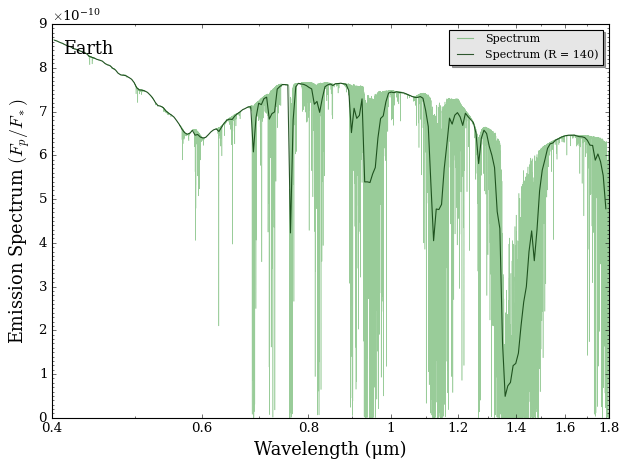

In [6]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Compute the spectrum
spectrum_FpFs, albedo = compute_spectrum(planet, star, model, atmosphere, opac, wl, \
                                    spectrum_type = 'emission', return_albedo = True, use_photosphere_radius= True)

spectra = []   # Empty plot collection

# Add the three model spectra to the plot collection object
spectra = plot_collection(spectrum_FpFs, wl, collection = spectra)

# Plot the spectra
fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = True,
                        y_unit = 'Fp/Fs', 
                        colour_list = ['green'])

Cool, we have a spectrum! Now let's add some *very* simple constant noise to the data at the expected nominal wavelength resolution of the Habitable Worlds Observatory. We will just apply simple Gaussian noise to a $\mathcal{R}=140$ spectra. We can then plot it with the forward model to see what it looks like.

Creating synthetic data
POSEIDON does not currently have an instrument transmission function for HWO, so a box function will be used.
POSEIDON does not currently have an instrument transmission function for HWO, so a box function will be used.


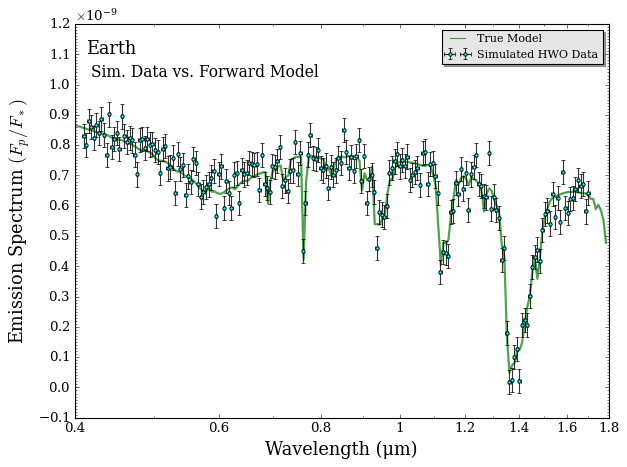

In [7]:
from POSEIDON.instrument import generate_syn_data_from_user
from POSEIDON.core import load_data

data_dir = './POSEIDON_output/' + planet_name
instrument = 'HWO'

generate_syn_data_from_user(planet, wl, spectrum_FpFs, data_dir, 
                            instrument, R_data = 140, err_data = 4e-5,
                            wl_start = 0.41, wl_end = 1.7,
                            label = 'Simple', 
                            Gauss_scatter = True)


datasets = ['Earth_SYNTHETIC_HWO_Simple.dat']

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, [instrument], wl)


fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = False,
                        spectra_labels = ['True Model'],
                        colour_list = ['forestgreen'], 
                        plt_label = ('Sim. Data vs. Forward Model'),
                        y_unit = 'Fp/Fs',
                        y_min = -1e-10, y_max = 1.2e-9,
                        wl_min = 0.4, wl_max = 1.8,
                        show_data = True,
                        data_properties = data,
                        data_labels = ['Simulated HWO Data'],
                        data_colour_list = ['cyan'],
                        data_marker_list = ['o'],
                        data_marker_size_list = [3],
                        )